<a href="https://colab.research.google.com/github/vaishnavi2022121/CODE-A-NOVA/blob/main/iris_flowers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['species']=iris.target
print(df.head())
print(df.shape)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
(150, 5)


In [3]:
df['species_name'] = df['species'].map({0:'setosa', 1:'versicolor', 2:'virginica'})
print(df['species_name'].value_counts())

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


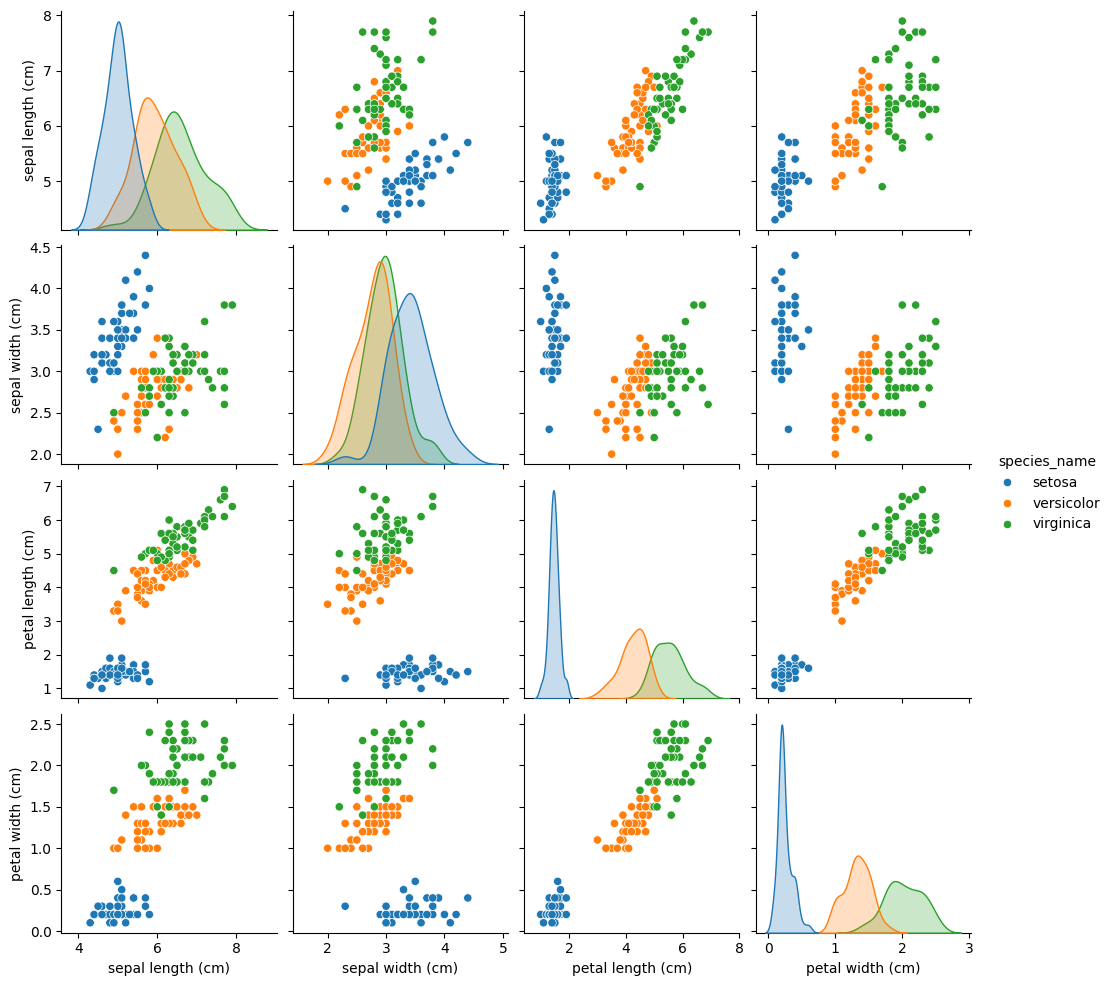

In [4]:
import seaborn as sns
sns.pairplot(df, hue='species_name', vars=iris.feature_names)

In [5]:
from sklearn.model_selection import train_test_split

X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(120, 4) (30, 4)


In [6]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [7]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



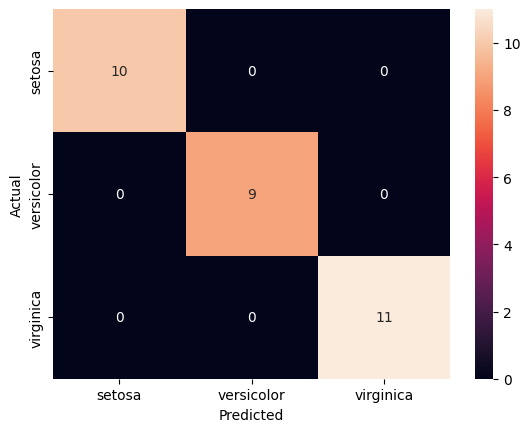

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Iris Flower Classification
A machine learning project to classify iris flowers into 3 species
(setosa, versicolor, virginica) using 4 measurements: sepal length,
sepal width, petal length, and petal width.

## Approach
- Loaded the Iris dataset from scikit-learn
- Explored the data with pairplots to check class separability
- Split data 80/20 into train/test sets
- Trained a K-Nearest Neighbors classifier (k=3)
- Evaluated using accuracy score and confusion matrix

## Result
Achieved 100% accuracy on the test set.